In [6]:
""" BLOCK 1: SAMPLE TRAINING DATA """
import os, glob, re, shutil
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path
from datetime import datetime
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import box, mapping
from tqdm import tqdm
import xml.etree.ElementTree as ET
import pyarrow.parquet as pq
import pyarrow as pa
from numba import njit

# Numba Helper for Quick Processing
@njit(parallel=True, fastmath=True)
def valid_mask_from_udm2(udm2, clear_idx=1):
    """
    Returns True for clear pixels using UDM2.
    UDM2 band 1 = 'Clear' (0 or 1)
    """
    mask = np.zeros(udm2.shape[1:], dtype=np.bool_)
    h, w = udm2.shape[1], udm2.shape[2]
    for i in range(h):
        for j in range(w):
            if udm2[clear_idx-1, i, j] == 1:
                mask[i, j] = True
    return mask

def sample_valid_pixels(valid_mask, n, seed=None):
    """Randomly sample n valid pixel coordinates"""
    if seed is not None:
        np.random.seed(seed)
    ys, xs = np.nonzero(valid_mask)
    if len(ys) == 0:
        return np.empty(0, dtype=np.int64), np.empty(0, dtype=np.int64)
    if n >= len(ys):
        return ys, xs
    idx = np.random.choice(len(ys), size=n, replace=False)
    return ys[idx], xs[idx]

# Planet XML Parser
def parse_planet_xml(xml_path):
    """Extracts basic metadata from a PlanetScope product XML."""

    meta = {
        "latitude": np.nan,
        "longitude": np.nan,
        "DOY": np.nan,
        "orbitDirection": np.nan,
        "incidenceAngle": np.nan,
        "illuminationAzimuthAngle": np.nan,
        "illuminationElevationAngle": np.nan,
        "azimuthAngle": np.nan,
        "spaceCraftViewAngle": np.nan
    }

    if not os.path.exists(xml_path):
        return meta

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f"Error parsing XML {xml_path}: {e}")
        return meta

    ns = {}
    for _, (prefix, uri) in ET.iterparse(xml_path, events=['start-ns']):
        ns[prefix] = uri

    ns.setdefault('ps',  'http://schemas.planet.com/ps/v1/planet_product_metadata_geocorrected_level')
    ns.setdefault('eop', 'http://earth.esa.int/eop')
    ns.setdefault('opt', 'http://earth.esa.int/opt')
    ns.setdefault('gml', 'http://www.opengis.net/gml')

    def find_text(tag):
        try:
            el = root.find(f".//{tag}", ns)
            if el is not None and el.text:
                return el.text.strip()
        except Exception:
            pass
        for el in root.iter():
            if el.tag.endswith(tag.split(':')[-1]) and el.text:
                return el.text.strip()
        return None

    lat_txt = find_text("ps:latitude")
    lon_txt = find_text("ps:longitude")
    if lat_txt and lon_txt:
        try:
            meta["latitude"] = float(lat_txt)
            meta["longitude"] = float(lon_txt)
        except ValueError:
            pass

    acq_time = find_text("ps:acquisitionDateTime") or find_text("gml:beginPosition")
    if acq_time:
        try:
            dt = datetime.fromisoformat(acq_time.replace("Z", "+00:00"))
            meta["DOY"] = dt.timetuple().tm_yday
        except Exception:
            pass

    tag_map = {
        "eop:orbitDirection": "orbitDirection",
        "eop:incidenceAngle": "incidenceAngle",
        "opt:illuminationAzimuthAngle": "illuminationAzimuthAngle",
        "opt:illuminationElevationAngle": "illuminationElevationAngle",
        "ps:azimuthAngle": "azimuthAngle",
        "ps:spaceCraftViewAngle": "spaceCraftViewAngle"
    }

    for tag, key in tag_map.items():
        val = find_text(tag)
        if val:
            try:
                meta[key] = float(val)
            except ValueError:
                meta[key] = val

    return meta

# Main function for image sampling
def generate_planet_training_parquet(base_dir, study_site, lake_shp, out_training_path, num_samples_per_lake=5):
    """
    Build a parquet training set of PlanetScope pixels sampled from 'ICE' and 'WATER' folders.
    Each lake polygon is sampled randomly within valid (clear) pixels from UDM2 mask.
    Lakes are reprojected to match each raster's CRS on the fly.
    """

    site_dir = os.path.join(base_dir, study_site)
    class_folders = {
        "ice": os.path.join(site_dir, "_ICE"),
        "water": os.path.join(site_dir, "_WATER")
    }

    records = []
    for label, fdir in class_folders.items():
        for tif in glob.glob(os.path.join(fdir, "*.tif")):
            fname = os.path.basename(tif).lower()
            if "udm" in fname or "mask" in fname or "visual" in fname:
                continue
            records.append({"scene_path": tif, "class": label})

    df_class = pd.DataFrame(records)
    print(f"Loaded {len(df_class)} samples ({df_class['class'].value_counts().to_dict()})")

    # Load lake polygons — CRS will be reprojected per-scene to match raster
    gdf_lakes = gpd.read_file(lake_shp)
    print(f"Loaded {len(gdf_lakes)} lake polygons (source CRS: {gdf_lakes.crs})")

    all_samples = []

    for _, rec in tqdm(df_class.iterrows(), total=len(df_class), desc="Processing scenes"):
        img_path = rec["scene_path"]
        label = rec["class"]
        folder = os.path.dirname(img_path)
        fname = os.path.basename(img_path)

        base_name = re.sub(r'(_analytic.*)?\.tif$', '', fname, flags=re.IGNORECASE)

        xml_path = os.path.join(folder, base_name + ".xml")
        xml_alt1 = os.path.join(folder, base_name + "_analytic_4b_xml.xml")
        xml_alt2 = os.path.join(folder, base_name + "_analytic_xml.xml")
        for alt in [xml_alt1, xml_alt2]:
            if not os.path.exists(xml_path) and os.path.exists(alt):
                xml_path = alt

        udm_path = os.path.join(folder, base_name + "_udm2.tif")
        if not os.path.exists(udm_path):
            print(f"No UDM2 for {base_name}, skipping.")
            continue

        xml_meta = parse_planet_xml(xml_path)
        if xml_meta is None:
            xml_meta = {}

        # Load SR image and get raster CRS
        with rasterio.open(img_path) as src_analytic:
            analytic = src_analytic.read()
            transform = src_analytic.transform
            height, width = src_analytic.height, src_analytic.width
            raster_crs = src_analytic.crs

        band_names = [f"band{i+1}" for i in range(analytic.shape[0])]

        # Load UDM2 and derive clear pixel mask
        with rasterio.open(udm_path) as src_udm:
            udm2 = src_udm.read()
        valid_mask = valid_mask_from_udm2(udm2)

        # Reproject lakes to match raster CRS on the fly
        gdf_lakes_reproj = gdf_lakes.to_crs(raster_crs)

        # Find lakes that intersect this scene
        raster_bounds = box(*rasterio.transform.array_bounds(height, width, transform))
        lakes_in_scene = gdf_lakes_reproj[gdf_lakes_reproj.intersects(raster_bounds)]
        if lakes_in_scene.empty:
            continue

        geoms = [
            mapping(l.geometry.intersection(raster_bounds))
            for _, l in lakes_in_scene.iterrows() if not l.geometry.is_empty
        ]
        lake_mask = ~geometry_mask(
            geoms,
            transform=transform,
            invert=True,
            out_shape=(height, width)
        )

        combined_mask = valid_mask & lake_mask

        # Random sampling
        total_samples = num_samples_per_lake * len(geoms)
        ys, xs = sample_valid_pixels(combined_mask, total_samples, seed=42)
        if len(ys) == 0:
            continue

        sample_records = []
        for y, x in zip(ys, xs):
            sdict = {band_names[b]: float(analytic[b, y, x])
                     for b in range(analytic.shape[0])}
            sdict.update({
                "scene": base_name,
                "label": label,
                "row": int(y),
                "col": int(x)
            })
            sdict.update(xml_meta)
            sample_records.append(sdict)

        if sample_records:
            all_samples.append(pd.DataFrame(sample_records))

    # Save / Output
    if not all_samples:
        print("No samples generated after filtering.")
        return

    df_all = pd.concat(all_samples, ignore_index=True)
    os.makedirs(os.path.dirname(out_training_path), exist_ok=True)
    pq.write_table(pa.Table.from_pandas(df_all), out_training_path)

    print(f"\nSaved {len(df_all)} Planet training samples to {out_training_path}")
    print("Columns:", list(df_all.columns))


# Run code below:
study_sites = ["YKD", "NS"]

for study_site in study_sites:
    output_path = rf"E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\{study_site}_Freezeup\{study_site}_planet_training.parquet"

    generate_planet_training_parquet(
        base_dir=r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF",
        study_site=study_site,
        lake_shp=rf"E:\planetscope_lake_ice\Data\Input\Study Sites - Manual ALPOD Data\{study_site} 50x50 km\{study_site} Lakes from ALPOD Shapefile\{study_site}_50x50km_lakes.shp",
        out_training_path=output_path,
        num_samples_per_lake=12
    )

Loaded 40 samples ({'ice': 20, 'water': 20})
Loaded 8333 lake polygons (source CRS: EPSG:3338)


Processing scenes: 100%|██████████| 40/40 [03:46<00:00,  5.67s/it]



Saved 436388 Planet training samples to E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\YKD_Freezeup\YKD_planet_training.parquet
Columns: ['band1', 'band2', 'band3', 'band4', 'scene', 'label', 'row', 'col', 'latitude', 'longitude', 'DOY', 'orbitDirection', 'incidenceAngle', 'illuminationAzimuthAngle', 'illuminationElevationAngle', 'azimuthAngle', 'spaceCraftViewAngle']
Loaded 40 samples ({'ice': 20, 'water': 20})
Loaded 5694 lake polygons (source CRS: EPSG:3338)


Processing scenes: 100%|██████████| 40/40 [05:00<00:00,  7.51s/it]



Saved 478216 Planet training samples to E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\NS_Freezeup\NS_planet_training.parquet
Columns: ['band1', 'band2', 'band3', 'band4', 'scene', 'label', 'row', 'col', 'latitude', 'longitude', 'DOY', 'orbitDirection', 'incidenceAngle', 'illuminationAzimuthAngle', 'illuminationElevationAngle', 'azimuthAngle', 'spaceCraftViewAngle']



Training model for study site: YKD

Classes: ['ice', 'water'] -> [0, 1]

Splitting data: 80% train, 20% test...
Training samples: 349110
Test samples: 87278
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 500

Best CV accuracy: 0.9609
Best model CV train accuracy: 0.9943
Best model CV val accuracy: 0.9609
Classification Report (Test):
              precision    recall  f1-score   support

         ice       0.97      0.96      0.97     49451
       water       0.95      0.96      0.96     37827

    accuracy                           0.96     87278
   macro avg       0.96      0.96      0.96     87278
weighted avg       0.96      0.96      0.96     87278



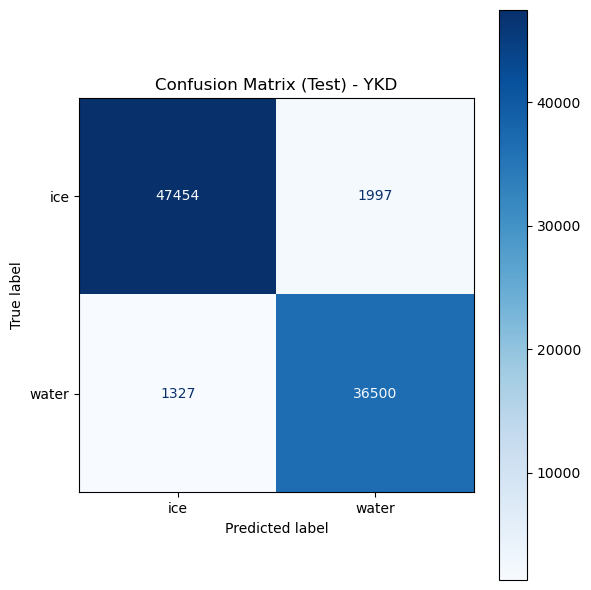

Final model trained

Feature importances (sorted):
1. band3     : 0.3845
2. band2     : 0.3160
3. band1     : 0.2340
4. band4     : 0.0655

Feature importance plot saved


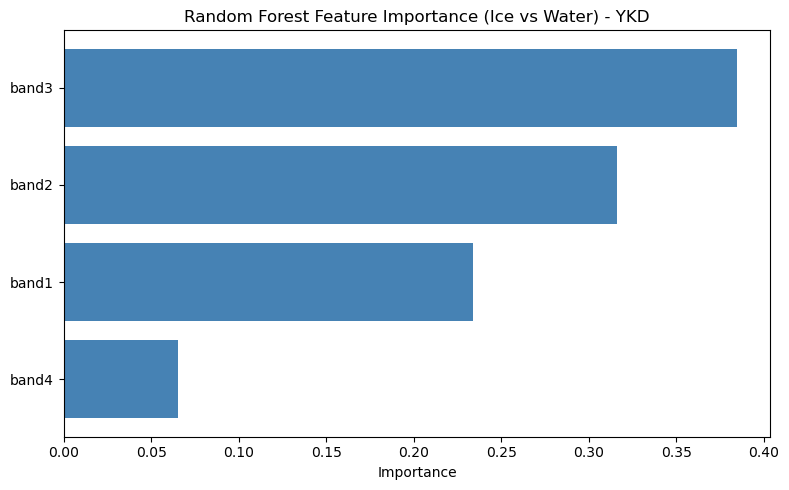

Feature importances exported to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\YKD_Freezeup\YKD_planet_training_feature_importance.csv
Model package saved to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\YKD_Freezeup\YKD_planet_training_RFmodel.joblib

Training model for study site: NS

Classes: ['ice', 'water'] -> [0, 1]

Splitting data: 80% train, 20% test...
Training samples: 382572
Test samples: 95644
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 500

Best CV accuracy: 0.8501
Best model CV train accuracy: 0.9932
Best model CV val accuracy: 0.8501
Classification Report (Test):
              precision    recall  f1-score   support

         ice       0.85      0.86      0.85     47768
       water       0.85      0.85      0.85     47876

    accuracy                           0.85     95644
   macro 

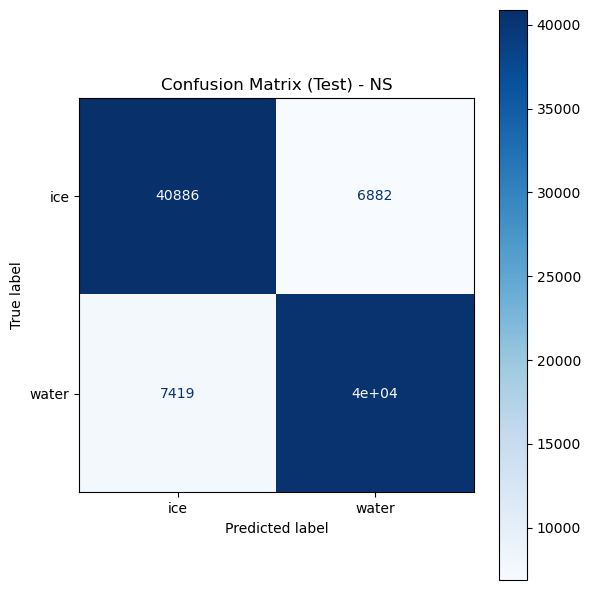

Final model trained

Feature importances (sorted):
1. band1     : 0.3810
2. band2     : 0.2476
3. band4     : 0.2099
4. band3     : 0.1614

Feature importance plot saved


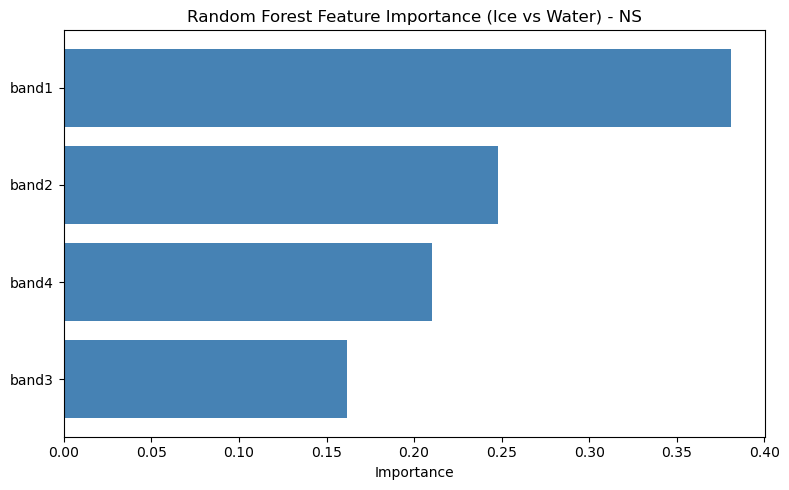

Feature importances exported to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\NS_Freezeup\NS_planet_training_feature_importance.csv
Model package saved to: E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\NS_Freezeup\NS_planet_training_RFmodel.joblib


In [7]:
""" BLOCK 2: TRAIN AND EVALUATE RANDOM FOREST W/ CV HYPERPARAMETER TUNING"""
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Run code below:
study_sites = ["YKD", "NS"]
test_size = 0.2  # Hold out 20% for final testing
random_state = 42

for study_site in study_sites:
    print(f"\n{'='*60}")
    print(f"Training model for study site: {study_site}")
    print(f"{'='*60}")

    # input filepaths
    base_dir = r"E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF"
    parquet_path = rf"E:\planetscope_lake_ice\Data\Input\Machine Learning - Planet Samples for RF\Models\{study_site}_Freezeup\{study_site}_planet_training.parquet"
    model_out_path = parquet_path.replace(".parquet", "_RFmodel.joblib")

    # load data
    df = pq.read_table(parquet_path).to_pandas()

    # drop unusable columns
    drop_cols = {
        "scene", "label", "row", "col",
        "orbitDirection", "DOY",
        "illuminationElevationAngle", "illuminationAzimuthAngle",
        "spaceCraftViewAngle", "incidenceAngle",
        "latitude", "longitude", "azimuthAngle"
    }

    # drop non-feature columns to exclude from RF
    feature_cols = [c for c in df.columns if c not in drop_cols]
    X = df[feature_cols].astype(float)

    # encode text labels ("ice"/"water")
    le = LabelEncoder()
    y = le.fit_transform(df["label"])
    print(f"\nClasses: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

    # train/test split
    print(f"\nSplitting data: {100*(1-test_size):.0f}% train, {100*test_size:.0f}% test...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # run model
    rf = RandomForestClassifier(random_state=random_state, n_jobs=-1)

    param_grid = {
        "n_estimators": [300, 400, 500],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt", "log2"],
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

    # fit model with cross validation on training set
    grid_search.fit(X_train, y_train)

    print("Best parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"  {param}: {value}")
    print(f"\nBest CV accuracy: {grid_search.best_score_:.4f}")

    # check for overfitting in CV
    cv_results = pd.DataFrame(grid_search.cv_results_)
    best_idx = grid_search.best_index_
    train_score = cv_results.loc[best_idx, 'mean_train_score']
    val_score = cv_results.loc[best_idx, 'mean_test_score']
    print(f"Best model CV train accuracy: {train_score:.4f}")
    print(f"Best model CV val accuracy: {val_score:.4f}")

    # evaluate on test set, print results
    best_model = grid_search.best_estimator_
    y_pred_test = best_model.predict(X_test)

    print("Classification Report (Test):")
    print(classification_report(y_test, y_pred_test, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix (Test) - {study_site}')
    plt.tight_layout()
    plt.savefig(model_out_path.replace("_RFmodel.joblib", "_confusion_matrix.png"), dpi=150)
    plt.show()

    # train final model on all data
    final_model = RandomForestClassifier(
        **grid_search.best_params_,
        random_state=random_state,
        n_jobs=-1
    )
    final_model.fit(X, y)
    print("Final model trained")

    # feature importance
    importances = final_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    sorted_features = [feature_cols[i] for i in indices]

    print("\nFeature importances (sorted):")
    for rank, (feat, imp) in enumerate(zip(sorted_features, importances[indices]), 1):
        print(f"{rank}. {feat:10s}: {imp:.4f}")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(sorted_features[::-1], importances[indices][::-1], color="steelblue")
    ax.set_xlabel("Importance")
    ax.set_title(f"Random Forest Feature Importance (Ice vs Water) - {study_site}")
    plt.tight_layout()
    plt.savefig(model_out_path.replace("_RFmodel.joblib", "_feature_importance.png"), dpi=150)
    print(f"\nFeature importance plot saved")
    plt.show()

    # save to CSV
    fi_df = pd.DataFrame({
        "band": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)
    fi_csv = model_out_path.replace("_RFmodel.joblib", "_feature_importance.csv")
    fi_df.to_csv(fi_csv, index=False)
    print(f"Feature importances exported to: {fi_csv}")

    # save trained model
    model_package = {
        "model": final_model,
        "label_encoder": le,
        "feature_columns": feature_cols,
        "best_params": grid_search.best_params_,
        "cv_score": grid_search.best_score_,
        "test_accuracy": (y_pred_test == y_test).mean(),
        "training_samples": len(df)
    }

    joblib.dump(model_package, model_out_path)
    print(f"Model package saved to: {model_out_path}")